In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import  seaborn as sns
from cyvcf2 import VCF
from pygenomeviz import Gff, GenomeViz
import copy

In [30]:
gff = pd.read_csv('../data/GCF_002891405.2_Csec_1.0_genomic_with_introns.gff', sep='\t', comment='#', header=None)
gff.columns = ['scaffold', 'origin','type', 'start', 'end', 'no_idea', 'strand', 'no_idea2', 'IDstring']

In [31]:
sc = pd.read_csv('../data/GCF_002891405.2_Csec_1.0_assembly_report.txt', sep='\t', comment='#', header=None)
scdict = {k[6]:k[4] for i,k in sc.iterrows()}

In [32]:
gff['scaffold_alt'] = [scdict[i] for i in gff.scaffold]

In [33]:
gff_gene_only = gff.loc[gff.type=='gene']
gff_gene_only['GID'] = [i.split(';')[0].split('=')[1] for i in gff_gene_only.IDstring]

In [38]:
prdm9 = gff_gene_only.loc[gff_gene_only.GID=='gene-LOC111864767']
prdm9_start = prdm9.start.iloc[0]
prdm9_end = prdm9.end.iloc[0]

prdm9_start = 306361
prdm9_end = 306798
prdm9_scaffold = prdm9.scaffold_alt.iloc[0]

In [42]:
prdm9_var

[Variant(NEVH01001345.1:306685 C/T),
 Variant(NEVH01001345.1:306753 T/C),
 Variant(NEVH01001345.1:306771 C/T),
 Variant(NEVH01001345.1:306792 T/C),
 Variant(NEVH01001345.1:306794 T/C),
 Variant(NEVH01001345.1:306796 A/G)]

In [35]:
prdm9_end

325449

In [39]:
vcf = VCF('../data/Csec_concat_geq1000_rm_indels_hard_filt_excesshet.vcf_biallelic_dpfilt_qualfilt_no_mac_maxmiss06_rmfilt_MQ70_dp2stdev.recode.vcf', threads=20)

In [40]:
prdm9_var = []
for variant in vcf:
    if variant.CHROM == prdm9_scaffold:
        if variant.POS > prdm9_start:
            if variant.POS < prdm9_end:
                prdm9_var.append(variant)         

In [41]:
len(prdm9_var)

6

In [13]:
gt_alt=[]
gt_ref = []
gt_aaf = []
gt_types = []
pos = []
for i in prdm9_var:
    gt_alt.append(i.ALT)
    gt_aaf.append(i.aaf)
    gt_types.append(i.gt_types)   
    pos.append(i.POS)
    gt_ref.append(i.REF)
gt_alt = [i[0] for i in gt_alt]

In [14]:
alt_af_df = pd.DataFrame([pos,gt_ref, gt_alt, gt_aaf]).T

In [15]:
alt_af_df.loc[alt_af_df[3]>0.5]

,0,1,2,3
1,304636,T,A,0.944444
135,308978,A,G,1.0
137,309017,T,C,1.0
232,312071,C,T,0.666667
464,319585,C,T,0.555556
669,325116,T,A,1.0
670,325117,T,G,1.0


In [136]:
print(prdm9_scaffold)

NEVH01001345.1


In [17]:
gtdf = pd.DataFrame(gt_types)

In [451]:
gtdf.index=pos

In [452]:
gtdf.columns = vcf.samples

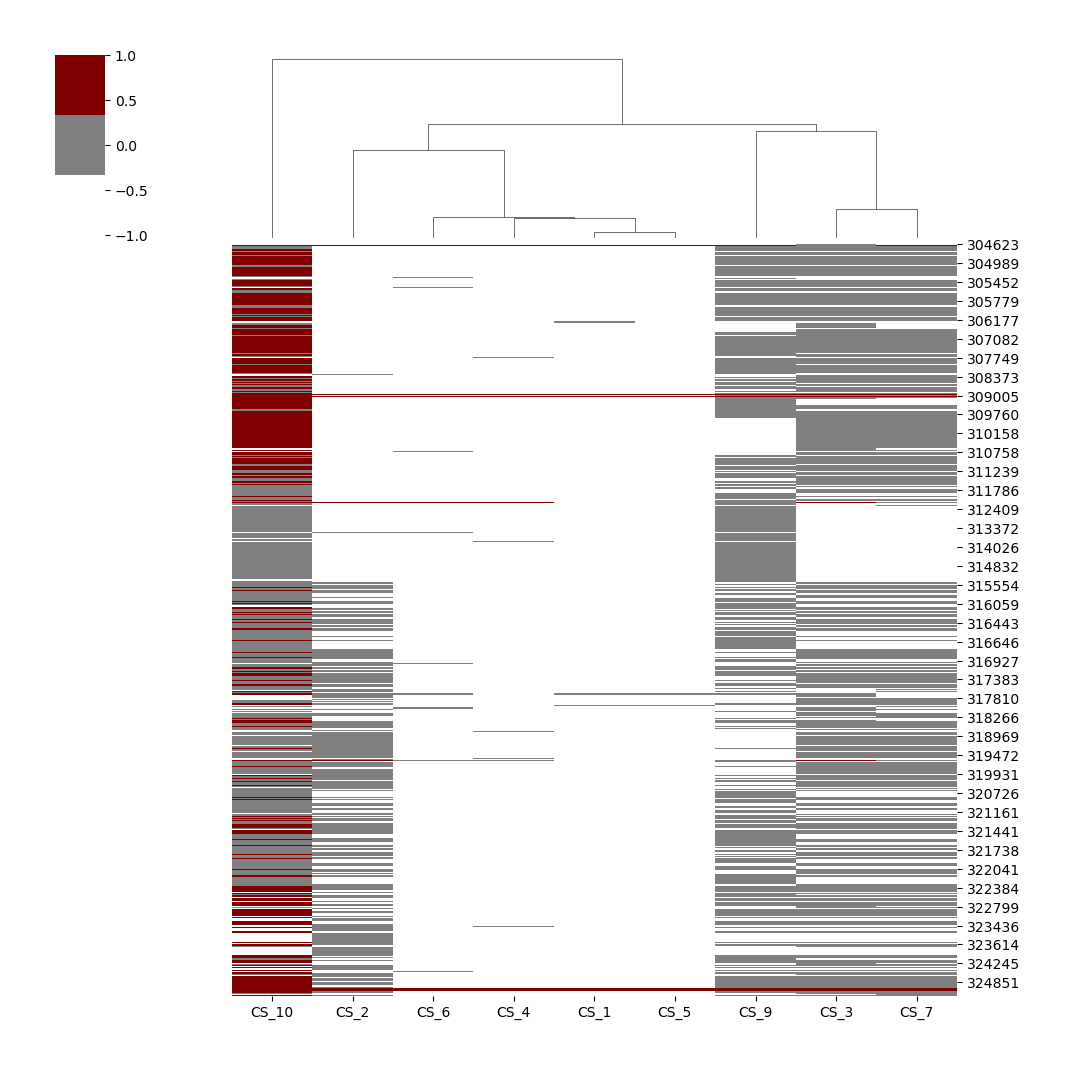

In [453]:
gtdf= gtdf.replace(2, np.nan)
gtdf= gtdf.replace(3, 2)
gtdf= gtdf.replace(0, -1)
gtdf= gtdf.replace(1, 0)
gtdf= gtdf.replace(2, 1)

sns.clustermap(gtdf, col_cluster=True, row_cluster=False, cmap=['white', 'grey', 'maroon'])

In [456]:
gtdf2 = copy.deepcopy(gtdf)

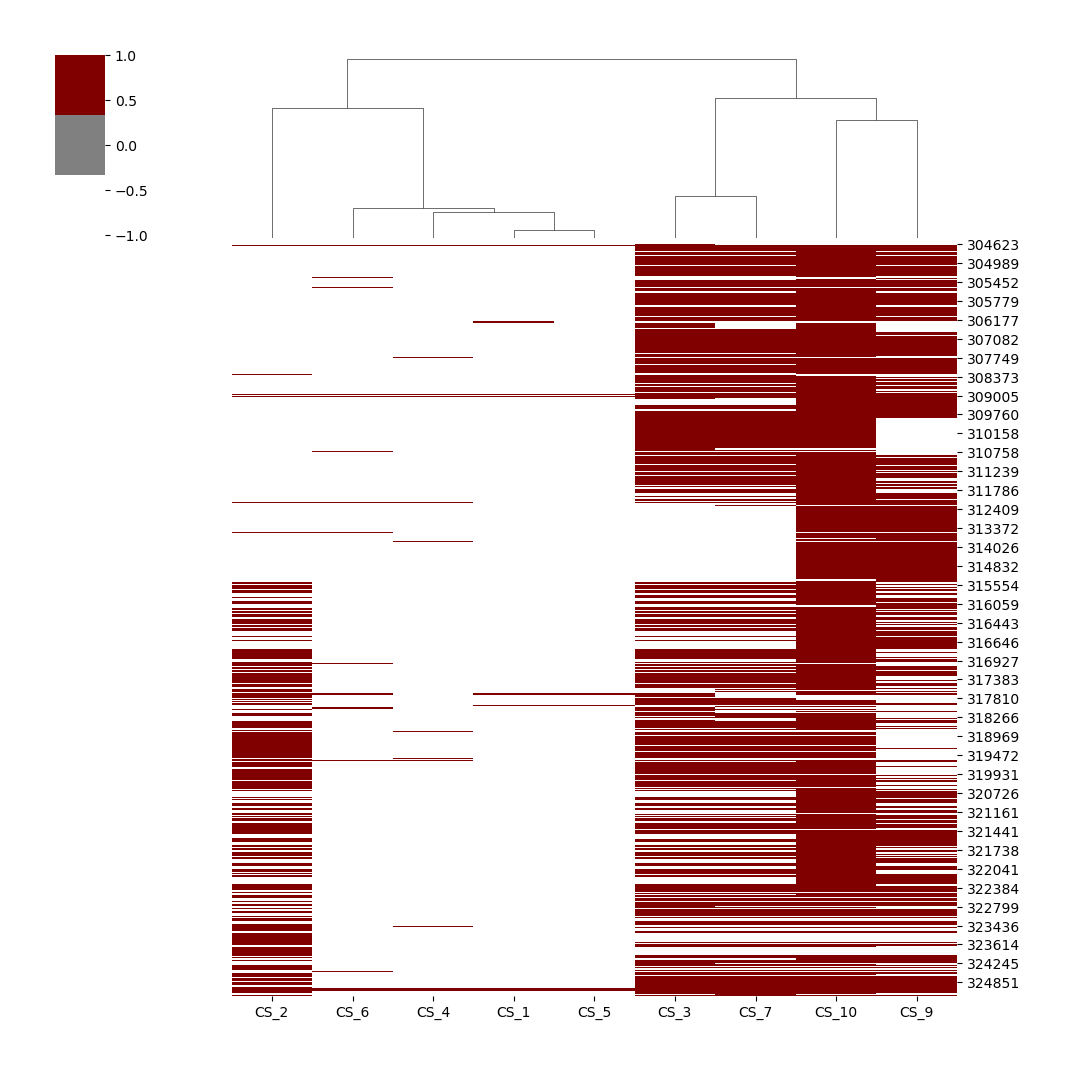

In [459]:
gtdf2=gtdf2.replace(0,1)
sns.clustermap(gtdf2, col_cluster=True, row_cluster=False, cmap=['white', 'grey', 'maroon'])

In [85]:
list(gtdf.T.loc['CS_1'].loc[gtdf.T.loc['CS_1']==3].index)

[304636, 308978, 309017, 325116, 325117]

In [129]:
gt_aaf = []
for i in prdm9_var:
    gt_aaf.append(i.aaf)

In [354]:
gt_div = []
for i in prdm9_var:
    gt_div.append(i.nucl_diversity)

In [ ]:
for i in prdm9_var:
    

In [26]:
gff_file = "../data/Genes_INSDC_annotation_provided_by_Westfaelische_Wilhelms_Univ.GFF3"

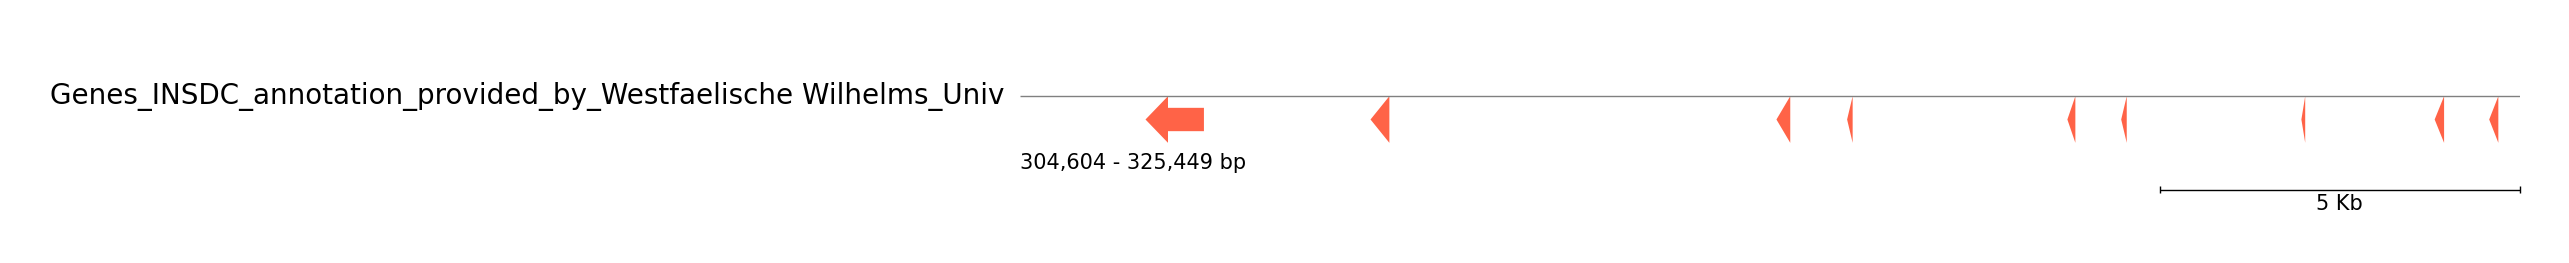

In [302]:

gff = Gff(gff_file,min_range=304604, max_range=325449)

gv = GenomeViz(fig_track_height=0.7, tick_track_ratio=0.5, tick_style="bar")
track = gv.add_feature_track(gff.name, size=gff.range_size, start_pos=gff.min_range)
track.add_gff_features(gff, plotstyle="arrow", facecolor="tomato")
track.set_sublabel()



f =gv.plotfig()

plt.show()

In [27]:
prdm9_features = pd.read_csv(gff_file, sep='\t', header=None, comment='#')

In [25]:
#prdm9_features.loc[prdm9_features[2]=='exon'] #[8].iloc[0,]

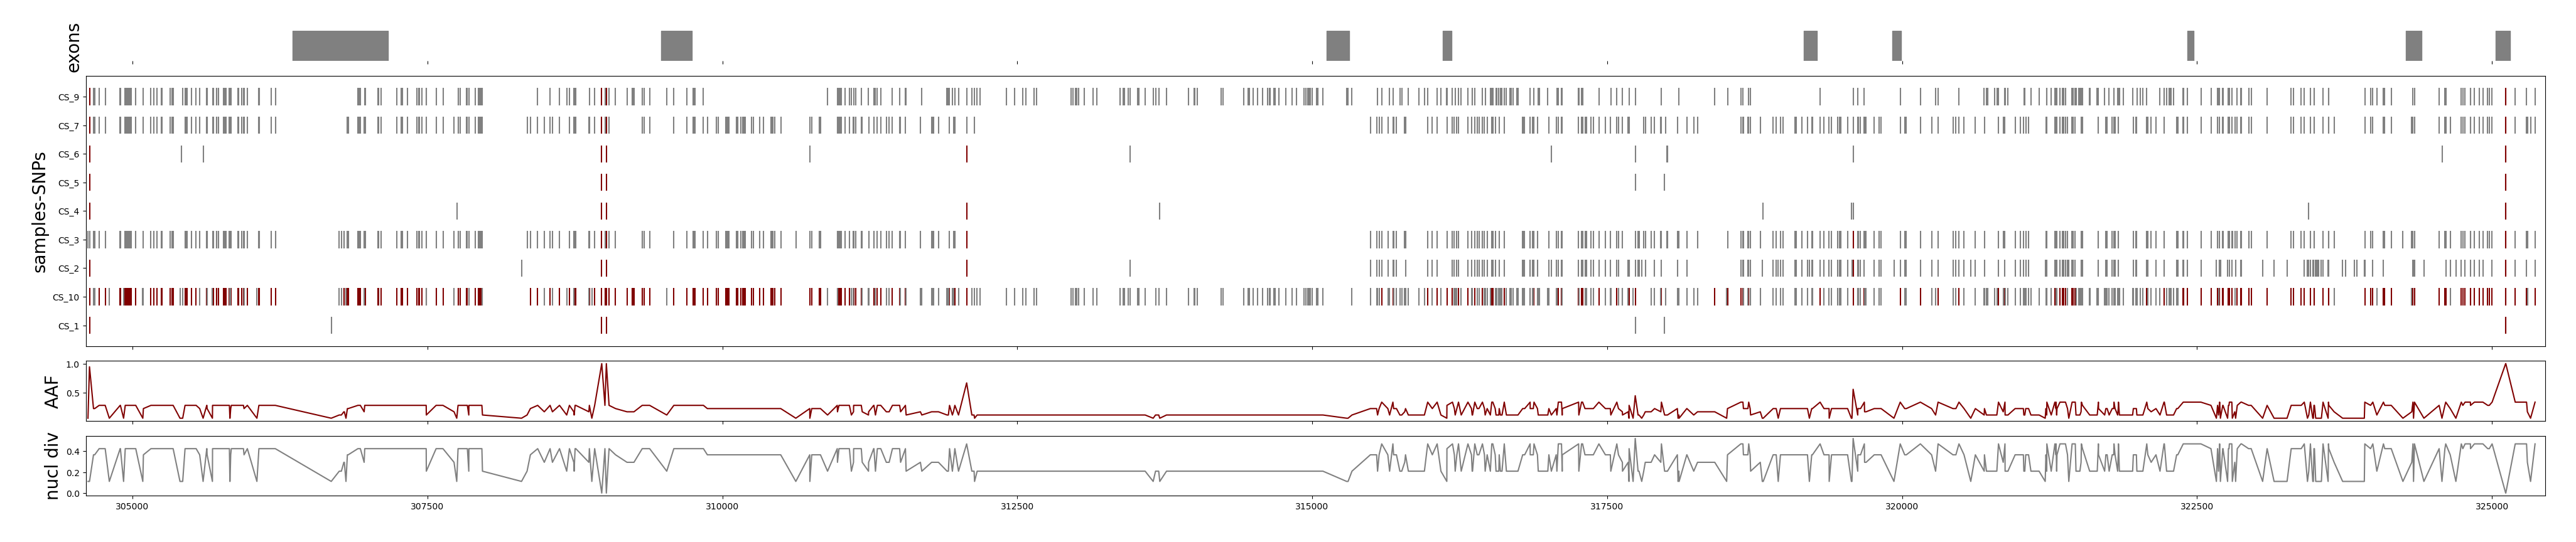

In [357]:
fig, (ax0,ax,ax1,ax2) = plt.subplots(ncols=1, nrows=4, figsize=(40,8),gridspec_kw={'height_ratios':(5,45,10,10)}, sharex=True
)
for i, (samplename, sample) in enumerate(gtdf.T.iterrows()):
    #print(samplename)
    #print(sample.loc[sample==3].index)
    hom_alt_arr  = list(sample.loc[sample==3].index)
    het_alt_arr  = list(sample.loc[sample==1].index)
    #print(hom_alt_arr)
    ax.vlines(hom_alt_arr, ymin=i-0.3, ymax=i+0.3, color='maroon', label='Homozygous')
    ax.vlines(het_alt_arr, ymin=i-0.3, ymax=i+0.3, color='grey', label='Heterozygous')
ax.set_yticks(list(range(0,9)))
ax.set_yticklabels(gtdf.columns)

for i,k in prdm9_features.loc[prdm9_features[2]=='exon'].iterrows():
    ax0.axvspan(k[3], k[4], color='grey')
    #ax0.text(k[3], 0.5, '<- exon', color='red', size=20)

ax1.plot(pos,gt_aaf, color='maroon')
ax2.plot(pos,gt_div, color='grey')

plt.tight_layout()

ax0.set_xlim(prdm9_start, prdm9_end)
ax.set_xlim(prdm9_start, prdm9_end)
ax1.set_xlim(prdm9_start, prdm9_end)

sns.despine(ax=ax0, bottom=True, left=True)

ax0.set_yticks([])

ax0.set_ylabel('exons', size=20)
ax.set_ylabel('samples-SNPs', size=20)
ax1.set_ylabel('AAF', size=20)
ax2.set_ylabel('nucl div', size=20)

plt.show()


In [391]:

prdm9_fasta = "../data/prdm9.fna"

In [398]:
with open(prdm9_fasta, 'rt') as handle:
    prdm9fna=handle.read().split("\n")

In [402]:
fa_handle = prdm9fna[0]

In [403]:
fa_seq = prdm9fna[1].upper()

In [475]:
gtdf[["CS_2","CS_10", "CS_4"]].loc[325300].max()

0

In [484]:
new_fa = []
min_aaf =0.0
individs = ["CS_6", "CS_4", "CS_1", "CS_5"]


altdict = {}
for i,k in alt_af_df.iterrows():
    altdict[k[0]]={"REF":k[1], "ALT":k[2], "AAF":k[3]}

oldfa= list(fa_seq)
for i,k in enumerate(oldfa):
    if i+1+prdm9_start in altdict:
        if altdict[i+1+prdm9_start]["REF"]==k:
            if altdict[i+1+prdm9_start]["AAF"]>min_aaf:
                if gtdf[individs].loc[i+1+prdm9_start].max()>-1:
                    new_fa.append(altdict[i+1+prdm9_start]["ALT"])
                else:
                    new_fa.append(k) 
            else:
                new_fa.append(k)
        else:
            raise IOError("uh-oh, seems like the reference fasta and REF allele in the VCF dont match - are your positions correct?")
    else:
        new_fa.append(k)
alt_seq = "".join(new_fa)

new_fafile = "../data/prdm9_alt_clust2.fna"


with open(new_fafile,"wt") as handle:
    handle.write(fa_handle+'\n')
    handle.write(alt_seq+'\n')